## Task 1: Data Preparation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the local CSV file.
df = pd.read_csv('brca.csv')

# Inspect the dataset structure.
print('Shape:', df.shape)
display(df.head())
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# The file includes a target column called y.
# Convert diagnosis to a binary target where 1 = benign and 0 = malignant.
df['target'] = df['y'].map({'B': 1, 'M': 0})

# Separate features and target.
X = df.drop(columns=['y', 'target'])
y = df['target']

# Some CSV exports include an index-like first column such as H1.
# If it is not useful for modeling, drop it after verifying the data.
if 'H1' in X.columns:
    X = X.drop(columns=['H1'])

print('\nFeature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Missing values per column:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Duplicate rows: 0

Feature matrix shape: (569, 31)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


## Task 2: Train-Test Split Analysis

In [2]:
def evaluate_knn_with_split(X, y, test_size, k_value, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = KNeighborsClassifier(n_neighbors=k_value)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    return {
        'test_size': test_size,
        'k': k_value,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1': f1_score(y_test, predictions),
    }

# Use a quick baseline K before heuristic tuning.
baseline_k = 5
split_results = pd.DataFrame([
    evaluate_knn_with_split(X, y, test_size=0.20, k_value=baseline_k),
    evaluate_knn_with_split(X, y, test_size=0.30, k_value=baseline_k),
    evaluate_knn_with_split(X, y, test_size=0.10, k_value=baseline_k),
])

split_results

,test_size,k,accuracy,precision,recall,f1
0,0.2,5,0.982456,1.000000,0.972222,0.985915
1,0.3,5,0.988304,0.990654,0.990654,0.990654
2,0.1,5,0.964912,0.972222,0.972222,0.972222


 70:30 split gave the best overall balance of metrics, while the 90:10 split was slightly weaker. That is likely because the test set is very small in the 90:10 case, so the evaluation becomes less stable. 

## Task 3: KNN with Heuristic K Selection

Here we use the rule $K = \sqrt{n}$ 

Heuristic K: 21


,k,accuracy
0,16,0.982456
1,18,0.991228
2,20,0.991228
3,22,0.982456
4,24,0.982456
5,26,0.982456


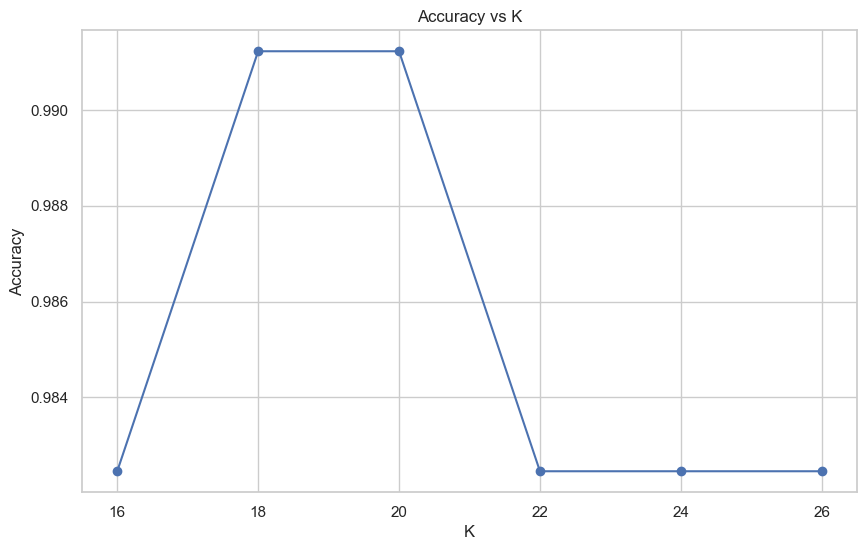

In [4]:
# Use the 80:20 split as the main validation setup for K tuning.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

heuristic_k = int(np.sqrt(len(X_train)))
if heuristic_k % 2 == 0:
    heuristic_k += 1

k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6, 2))
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    k_scores.append(accuracy_score(y_test, preds))

k_results = pd.DataFrame({'k': k_values, 'accuracy': k_scores})
print('Heuristic K:', heuristic_k)
display(k_results)

plt.plot(k_results['k'], k_results['accuracy'], marker='o')
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

optimal_k = int(k_results.loc[k_results['accuracy'].idxmax(), 'k'])


### Distance Metrics and Decision Boundary

KNN commonly uses Euclidean distance and Manhattan distance. This section shows how the decision boundary changes as K increases, which helps explain the bias-variance trade-off.

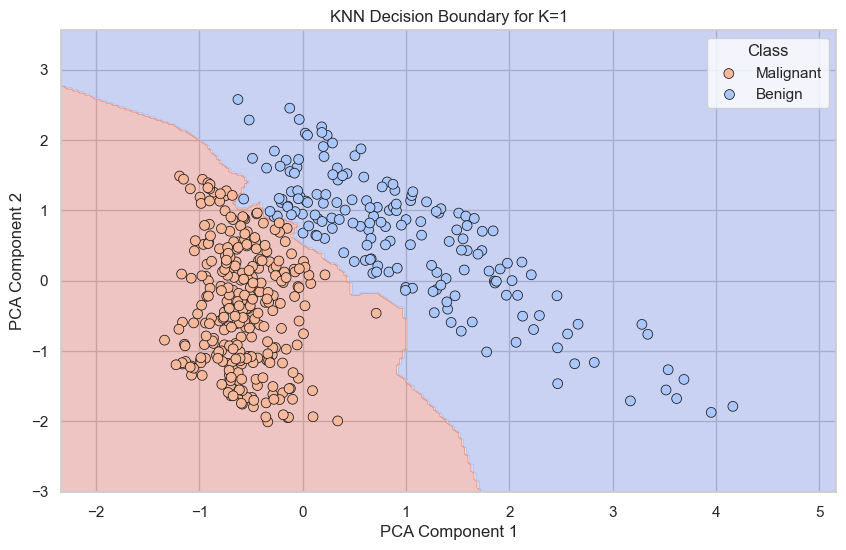

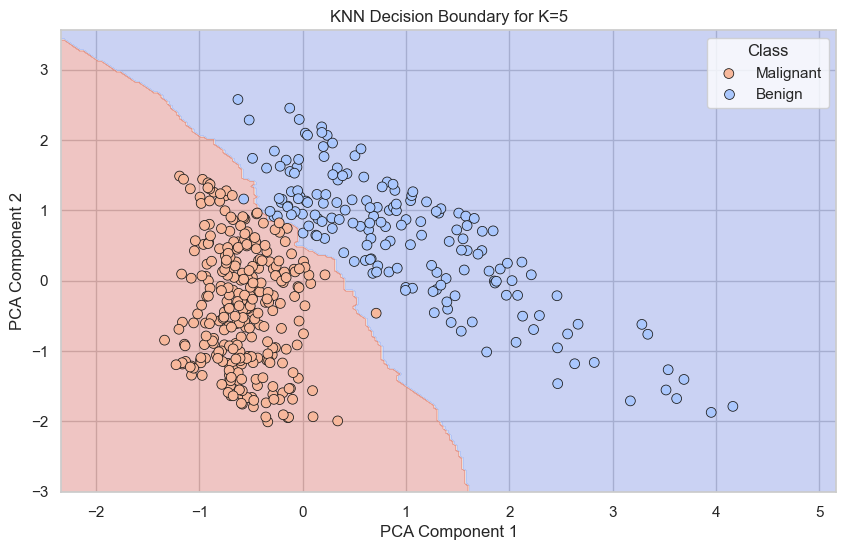

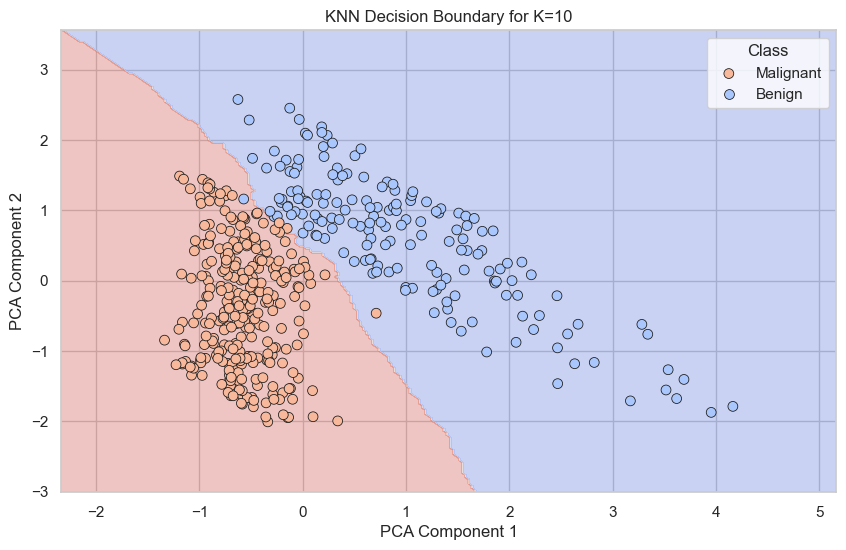

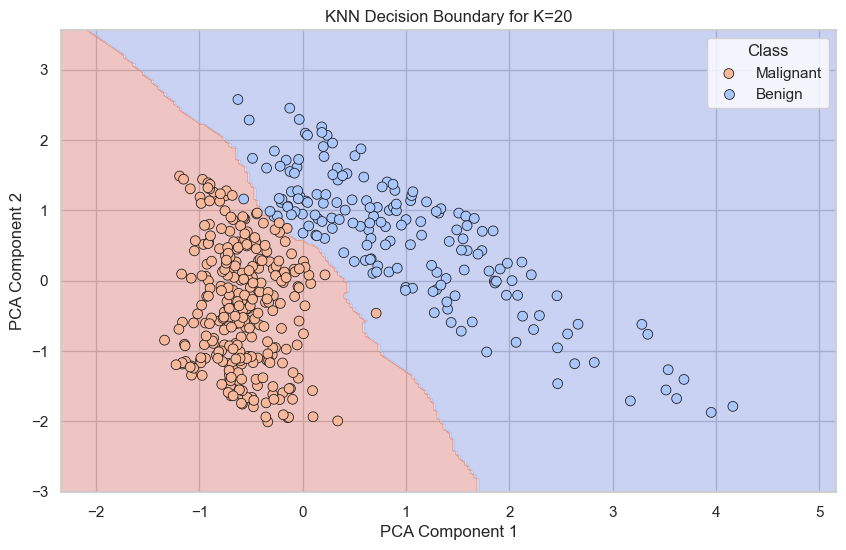

In [6]:
def plot_decision_boundary(X_data, y_data, k_value, title):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_data)

    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_2d, y_data, test_size=0.20, random_state=42, stratify=y_data
    )

    scaler_b = StandardScaler()
    X_train_b = scaler_b.fit_transform(X_train_b)
    X_test_b = scaler_b.transform(X_test_b)

    model = KNeighborsClassifier(n_neighbors=k_value)
    model.fit(X_train_b, y_train_b)

    x_min, x_max = X_train_b[:, 0].min() - 1, X_train_b[:, 0].max() + 1
    y_min, y_max = X_train_b[:, 1].min() - 1, X_train_b[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.03), np.arange(y_min, y_max, 0.03))
    grid_pred = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X_train_b[:, 0], y=X_train_b[:, 1], hue=y_train_b, palette='coolwarm', s=50, edgecolor='k')
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Class', labels=['Malignant', 'Benign'])
    plt.show()

for k in [1, 5, 10, 20]:
    plot_decision_boundary(X, y, k, f'KNN Decision Boundary for K={k}')


## Task 4: Cross Validation

In [7]:
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for k in k_values:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())

cv_results = pd.DataFrame({'k': k_values, 'mean_cv_accuracy': cv_scores})
display(cv_results)

best_k_cv = int(cv_results.loc[cv_results['mean_cv_accuracy'].idxmax(), 'k'])
print('Best K from cross-validation:', best_k_cv)

,k,mean_cv_accuracy
0,16,0.980671
1,18,0.973653
2,20,0.977162
3,22,0.977162
4,24,0.977162
5,26,0.973653


Best K from cross-validation: 16


## Task 5: Classification Evaluation

Final K: 16
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
AUC: 0.9990079365079365

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



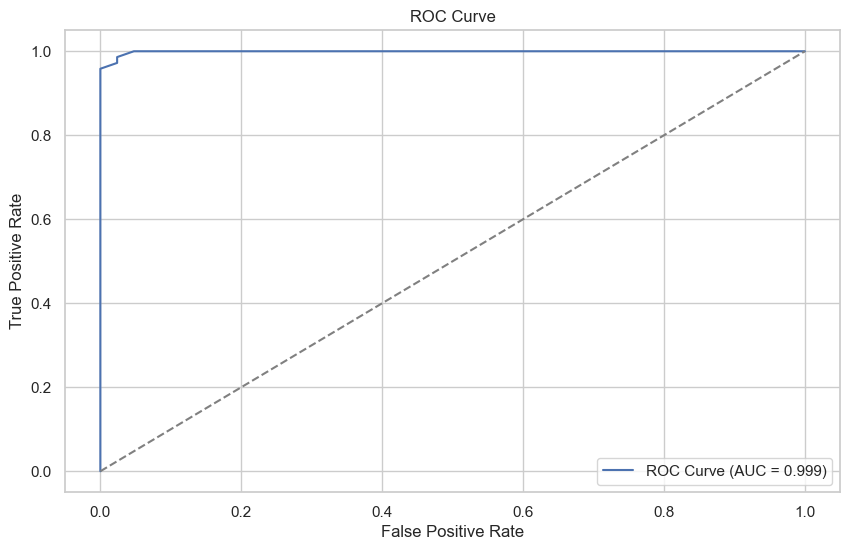

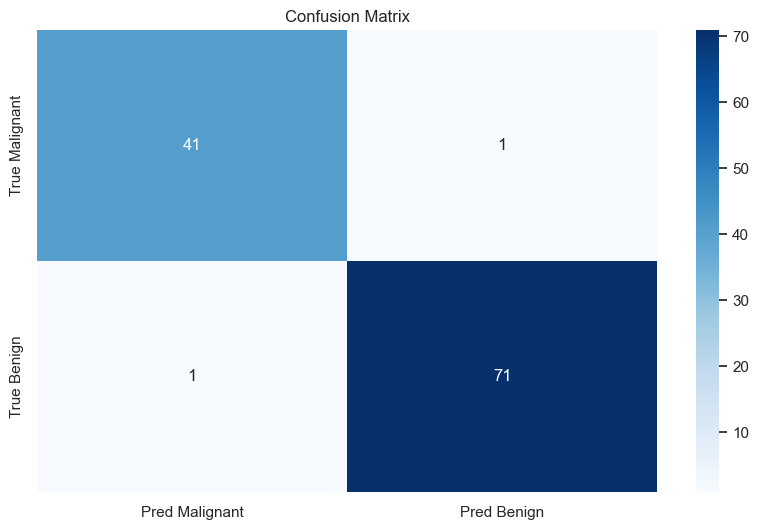

In [8]:
# Final model: pick the better K from nearby search and cross-validation.
final_k = best_k_cv if best_k_cv in k_values else optimal_k
final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train_scaled, y_train)
final_predictions = final_model.predict(X_test_scaled)
final_probabilities = final_model.predict_proba(X_test_scaled)[:, 1]

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)
final_conf_matrix = confusion_matrix(y_test, final_predictions)
final_auc = roc_auc_score(y_test, final_probabilities)

print('Final K:', final_k)
print('Accuracy:', final_accuracy)
print('Precision:', final_precision)
print('Recall:', final_recall)
print('F1 Score:', final_f1)
print('AUC:', final_auc)
print('\nConfusion Matrix:\n', final_conf_matrix)
print('\nClassification Report:\n', classification_report(y_test, final_predictions, target_names=['Malignant', 'Benign']))

fpr, tpr, thresholds = roc_curve(y_test, final_probabilities)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

sns.heatmap(final_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Malignant', 'Pred Benign'], yticklabels=['True Malignant', 'True Benign'])
plt.title('Confusion Matrix')
plt.show()

## Task 6: Comparative Study with Regression (Lab 3 Integration)

This section links the regression metrics from Lab 3 with the classification metrics used in Lab 4 so the difference in evaluation logic is clear.

### Regression vs Classification Metrics

- Regression metrics such as MAE, MSE, RMSE, and R² measure prediction error magnitude for continuous values.
- Classification metrics such as accuracy, precision, recall, F1, confusion matrix, and ROC-AUC measure whether class decisions are correct.
- In healthcare, recall and ROC-AUC are often more informative than accuracy because missing a positive case is much more serious than a false alarm.

### Short inference

Regression evaluation asks how far the predicted value is from the true value. Classification evaluation asks whether the predicted label is correct and whether the model is reliable for positive-case detection. Accuracy alone is not enough for cancer diagnosis because it can hide false negatives. Recall is more important because it shows how many actual cancer cases were detected. ROC-AUC is useful because it reflects the model’s ability to separate classes across thresholds.

## Task 7: Analytical Questions

These short answers can be used directly in the lab write-up after you run the notebook and observe the outputs.

1. KNN is called a lazy learning algorithm because it does not build an explicit model during training; it stores the training data and performs most of the computation at prediction time.
2. Feature scaling is required because KNN uses distance calculations, and features with larger numeric ranges would otherwise dominate the result.
3. The heuristic K selection rule $K = \sqrt{n}$ gives a simple starting point based on the training set size, but it should be refined using validation.
4. Cross-validation is more reliable than one train-test split because it averages performance across multiple folds instead of depending on one random split.
5. Small K values usually give low bias and high variance, while large K values give higher bias and lower variance.
6. Recall is more important than accuracy in cancer prediction because missing a true cancer case is more dangerous than a false alarm.
7. Very large K values can oversmooth the decision boundary and cause underfitting.